In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_rel
from driver_genes.data.utils import compute_pred, compute_sim
import itertools
import re


sns.set_theme(style='ticks', palette='Set2')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [2]:
ad_id_hek293ft = sc.read_h5ad('../results/kowalski/hek293ft_r2-seed42/anndata/preprocessed_HEK293FT_R1.h5ad')


In [3]:
ad_id_hek293ft_p = ad_id_hek293ft[~ad_id_hek293ft.obs['perturbation'].isin(['control', 'neg'])]
ad_id_hek293ft_p

View of AnnData object with n_obs × n_vars = 8899 × 22385
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes', 'replicate+lane', 'leiden', 'cluster', 'bc'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'cellline_colors', 'cluster_colors', 'hvg', 'lane_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'pertgenes', 'replicate+lane_colors', 'replicate_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'latent', 'proba', 'shift'
    varm: 'PCs'
    layers: 'X_hat', 'dy', 'raw'
    obsp: 'connectivities', 'distances'

In [4]:
compute_pred(ad_id_hek293ft_p)

AnnData object with n_obs × n_vars = 8899 × 22385
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes', 'replicate+lane', 'leiden', 'cluster', 'bc', 'pred_perturbation'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'cellline_colors', 'cluster_colors', 'hvg', 'lane_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'pertgenes', 'replicate+lane_colors', 'replicate_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'latent', 'proba', 'shift', 'rank', 'RelPos', 'logit'
    varm: 'PCs'
    layers: 'X_hat', 'dy', 'raw'
    obsp: 'connectivities', 'distances'

In [5]:
gene_list = ad_id_hek293ft_p.obs['pred_perturbation'].unique()

In [6]:
true_order = np.sort(ad_id_hek293ft_p.obs['perturbation'].unique())
pred_order = true_order[np.isin(true_order, ad_id_hek293ft_p.obs['pred_perturbation'].unique())]

In [7]:
count_df = (
    ad_id_hek293ft_p
    .obs[['perturbation', 'pred_perturbation']]
    .value_counts()
    .unstack()
    .fillna(0)
    .loc[pred_order, pred_order]
)

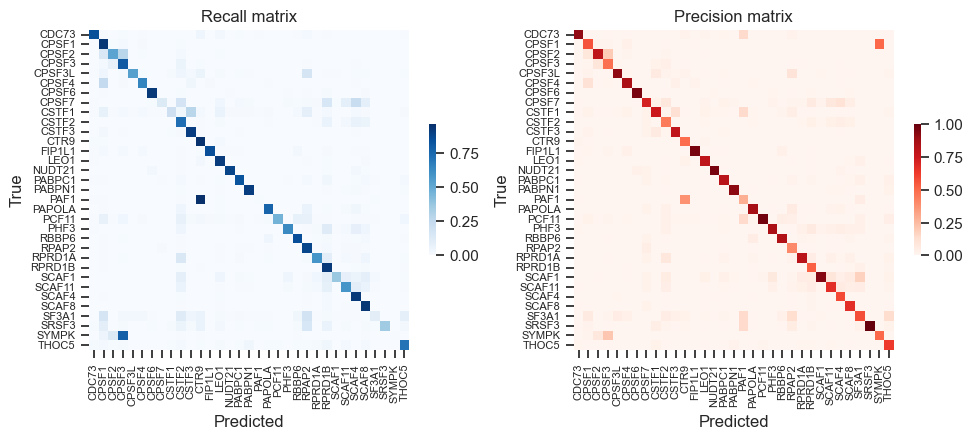

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.heatmap(
    count_df.transform(lambda x: x / x.sum(), axis=1), 
    square=True, 
    ax=axes[0], 
    cbar_kws={'shrink': 0.3}, 
    cmap='Blues'
)
axes[0].set_xticks(np.arange(count_df.shape[1])+0.5)
axes[0].set_xticklabels(count_df.columns.values, rotation=90, fontsize=8)
axes[0].set_yticks(np.arange(count_df.shape[0]) + 0.5)
axes[0].set_yticklabels(count_df.index.values, rotation=0, fontsize=8)
axes[0].set_title('Recall matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(
    count_df.transform(lambda x: x / x.sum(), axis=0), 
    square=True, 
    ax=axes[1], 
    cbar_kws={'shrink': 0.3}, 
    cmap='Reds'
)
axes[1].set_xticks(np.arange(count_df.shape[1]) + 0.5)
axes[1].set_xticklabels(count_df.columns.values, rotation=90, fontsize=8)
axes[1].set_yticks(np.arange(count_df.shape[0]) + 0.5)
axes[1].set_yticklabels(count_df.index.values, rotation=0, fontsize=8)
axes[1].set_title('Precision matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig('../figures/5_kowalski_hek293ft_r1_recall_precision.pdf')
plt.show()